In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
from diffusers import FluxPipeline, FluxControlNetPipeline, FluxControlNetModel, FluxControlPipeline
from diffusers.models import FluxMultiControlNetModel
from detector.canny_detect import CannyDetect
import torch
import json

/amax/hchuz/miniconda3/envs/py310/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


In [3]:
# control
model_id = "black-forest-labs/FLUX.1-dev"
pipe = FluxControlPipeline.from_pretrained(model_id, 
                                            torch_dtype=torch.bfloat16)
#pipe.enable_model_cpu_offload()
_ = pipe.to('cuda')
pipe.load_lora_weights("/amax/hchuz/hfd_models/FLUX.1-Canny-dev-lora", adapter_name="canny")
cannydetect = CannyDetect()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
pipe.load_lora_weights('/amax/hchuz/ai-toolkit/output/texture_caption_01/texture_caption_01.safetensors')

In [ ]:
pipe.load_lora_weights('/amax/hchuz/ai-toolkit/output/texture_caption_02/texture_caption_02.safetensors')

In [5]:
pipe.unload_lora_weights()

In [5]:
with open('/amax/hchuz/architectural_heritage/相似的几个2/Snipaste_2023-02-21_13-32-42.json', 'r') as f:
    data = json.load(f)

control_image = cannydetect.polygon2canny([sample['points'] for sample in data['shapes']])

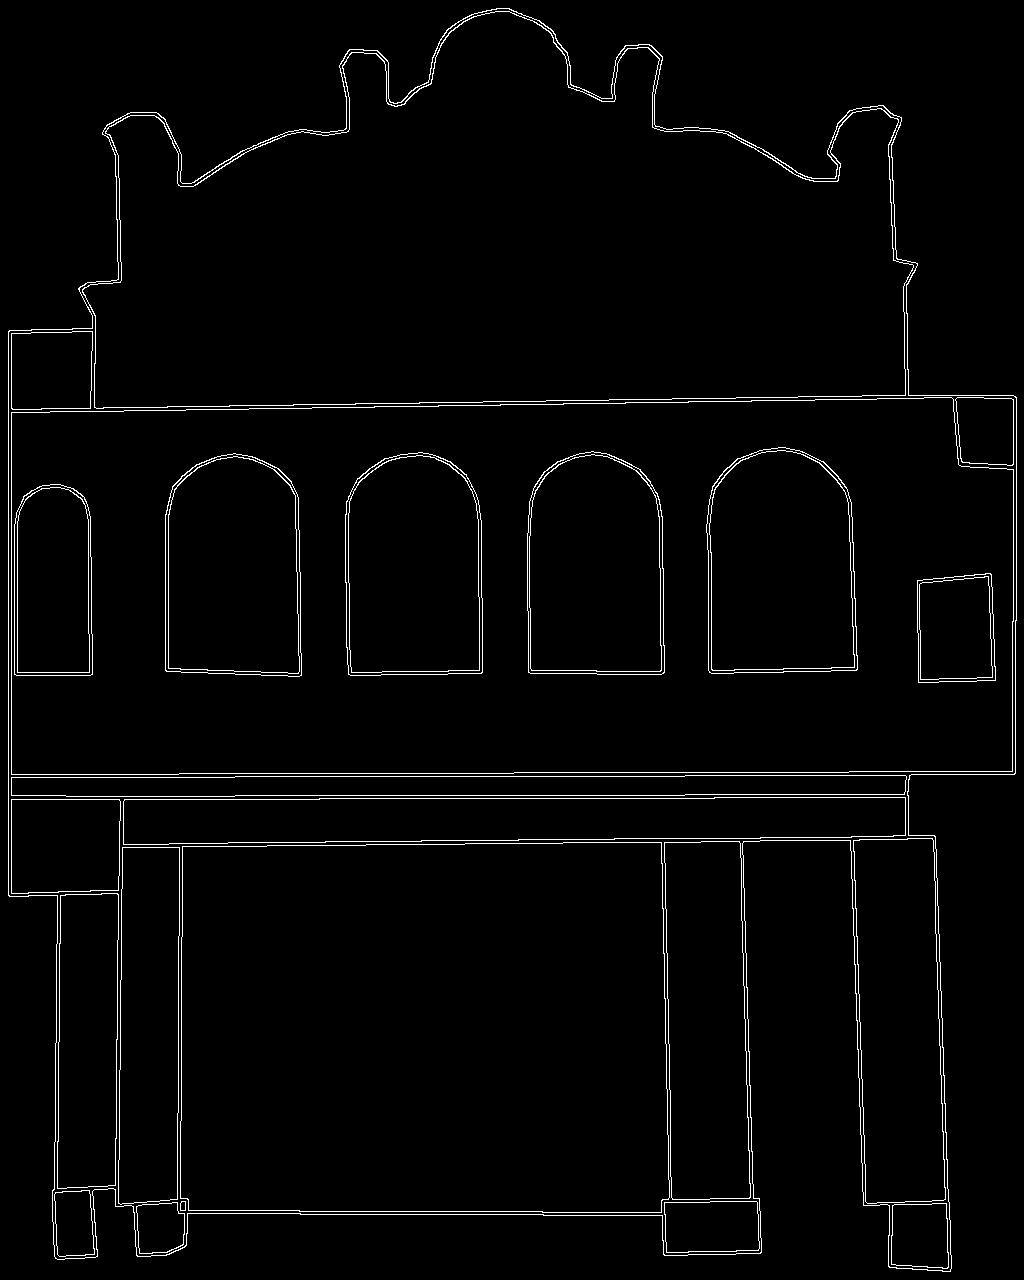

In [6]:
control_image

In [11]:
pipe.set_adapters("canny", 0.85)
kwargs = {
    'num_inference_steps':20, 
    'guidance_scale':3.5
    }

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['contributing to the white appearance. 2. ** windows **: the windows have wooden frames and shutters, which are painted in a dark color, possibly maroon or brown. 3. ** decorative elements **: the ornate decorative elements on the upper part of the facade, including the balustrades and moldings, are likely made of concrete or stone, possibly with some stucco work. 4. ** columns and pilasters **: the vertical supports and decorative columns appear to be made of stone or concrete, adding to the structural and aesthetic integrity of the building. 5. ** signage **: the signage above the entrance is made of metal or wooden letters affixed to the facade. 6. ** shutters **: the roller shutter at the entrance is made of metal, typically aluminum or steel, and is painted in a yellowish - green color. overall, the building combines traditional masonry materials with wooden and metal elements t

  0%|          | 0/20 [00:00<?, ?it/s]

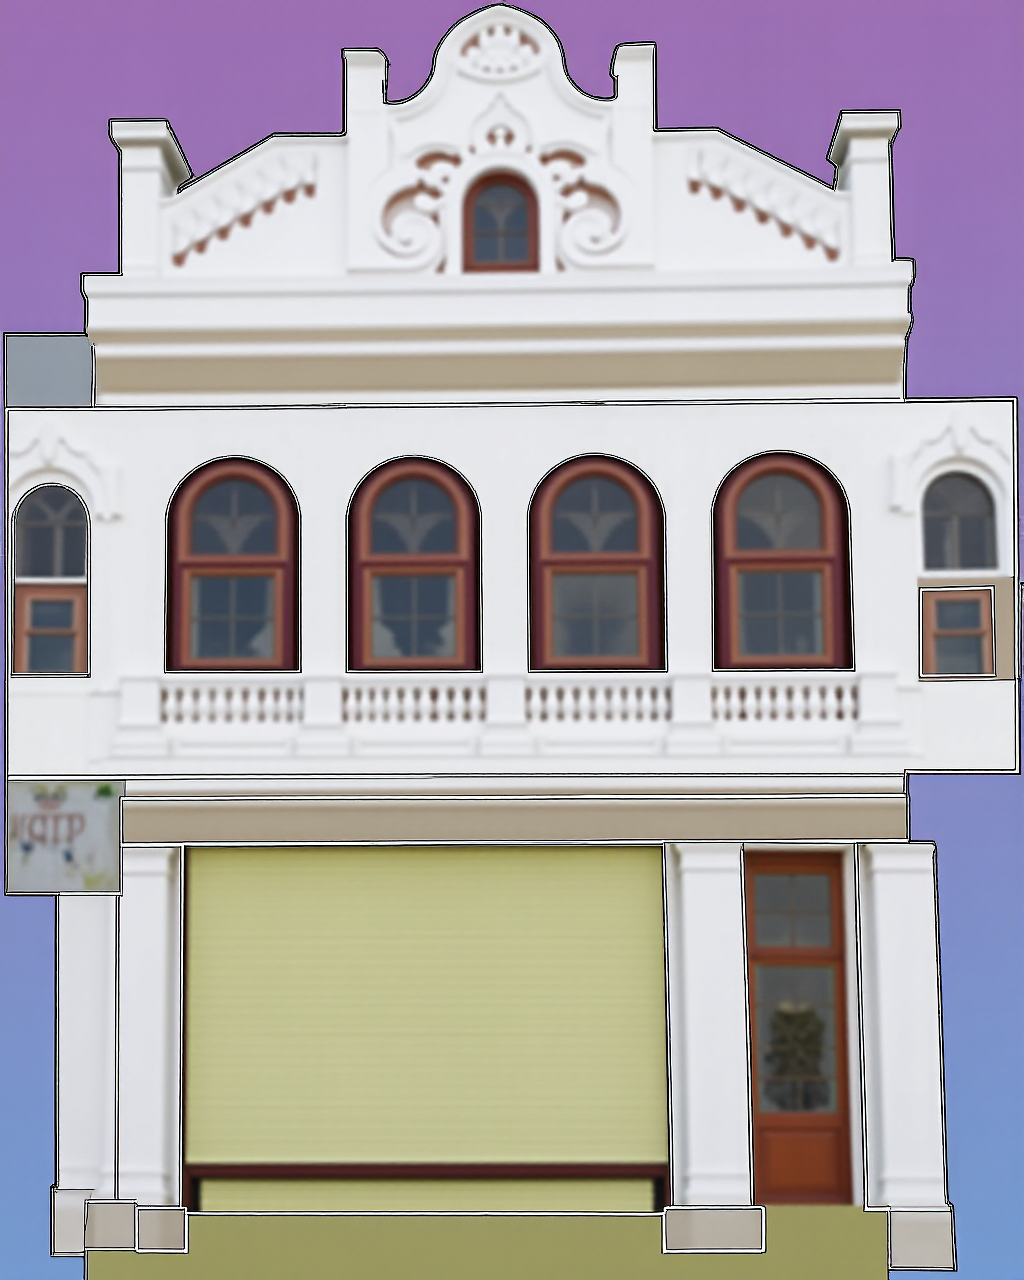

In [12]:
prompt = '''
[Stone, Granite, Concrete] The building in the image appears to be constructed with a combination of materials that are typical for traditional or colonial-style architecture. Here are some details about the materials:

1. **Facade**: The facade of the building is likely made of plaster or stucco, which gives it a smooth, textured finish. The plaster may be painted, contributing to the white appearance.

2. **Windows**: The windows have wooden frames and shutters, which are painted in a dark color, possibly maroon or brown.

3. **Decorative Elements**: The ornate decorative elements on the upper part of the facade, including the balustrades and moldings, are likely made of concrete or stone, possibly with some stucco work.

4. **Columns and Pilasters**: The vertical supports and decorative columns appear to be made of stone or concrete, adding to the structural and aesthetic integrity of the building.

5. **Signage**: The signage above the entrance is made of metal or wooden letters affixed to the facade.

6. **Shutters**: The roller shutter at the entrance is made of metal, typically aluminum or steel, and is painted in a yellowish-green color.

Overall, the building combines traditional masonry materials with wooden and metal elements to create a distinctive and ornate architectural style.
'''

images = pipe(prompt,
              control_image=[control_image],
              width=control_image.width,
              height=control_image.height,
              **kwargs)[0]
image = images[0]
image